### **Gradient Descent Regressor class from scratch**

In [289]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plot
import numpy as np

### **Forming sample dataset**

In [297]:
x,y = make_regression(
    n_samples = 60,
    n_features = 1,
    n_informative = 1,
    n_targets = 1,
    noise = 40
)

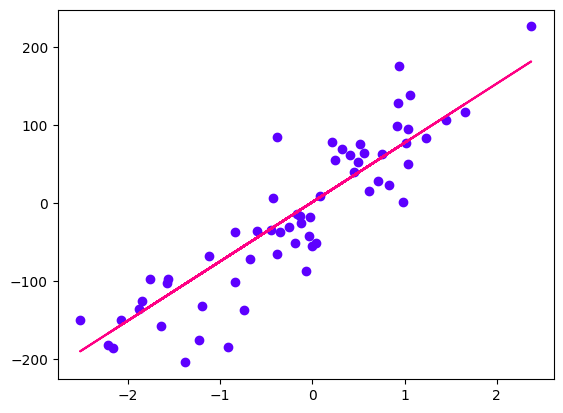

In [298]:
plot.scatter(x,y,color="#5d00ff")
plot.plot(x, lr.predict(x), color="#ff0084")

In [300]:
y.shape

(60,)

In [207]:
from sklearn.linear_model import LinearRegression

In [208]:
lr = LinearRegression()

In [301]:
lr.fit(x,y)

LinearRegression()

In [302]:
lr.coef_        # slope (m)

array([82.89021272])

In [303]:
lr.intercept_       # intercept (b)

np.float64(-2.4089125775484916)

In [304]:
# Assuming we know slope
m = lr.coef_

### **Class**

In [ ]:
class GDRegressor:

    def __init__(self, learning_rate, epochs):
        self.m = 100
        self.b = -100
        self.lr = learning_rate
        self.epochs = epochs
        
        self.b_list = []
        self.m_list = []
        self.loss_list = []

    def fit(self, x, y):

        X = x.reshape(len(x))
        Y = y.reshape(len(y))

        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(Y - self.m * X - self.b)
            loss_slope_m = -2 * np.sum((Y - self.m * X - self.b) * X)
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)

            self.b_list.append(self.b)
            self.m_list.append(self.m)

            y_pred = self.m * X + self.b
            
            loss = np.sum((Y - y_pred) ** 2)
            self.loss_list.append(loss)
            
        print("Final b:", self.b)
        print("Final m:", self.m)


In [344]:
gd = GDRegressor(0.001, 200)

In [345]:
gd.fit(x,y)

Final b: -2.408912586750238
Final m: 82.89021271301229


### **Visualisations**

### **Best fit line**

Final b: -10.203410560197089
Final m: 80.76506039242432


/tmp/ipykernel_2290/2464125967.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  line, = ax.plot(x_i, x_i * model.m_list[0] + model.b_list[0], 'r-', linewidth=2, color="#ff007b")


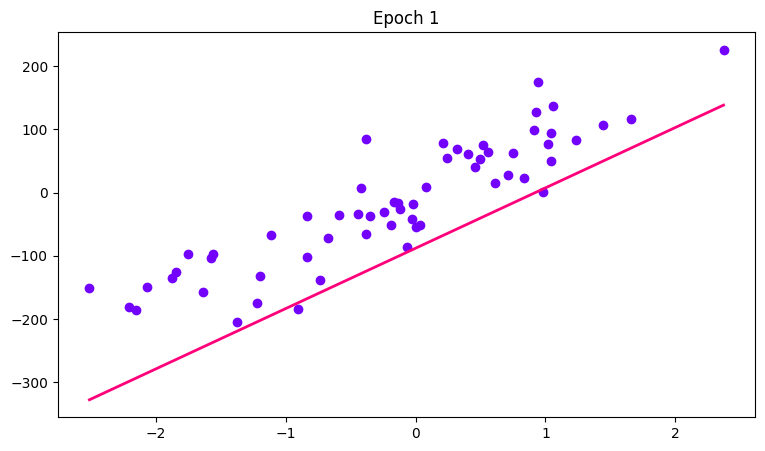

In [346]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

model = GDRegressor(learning_rate = 0.001, epochs = 20)
X = x.reshape(len(x))
Y = y.reshape(len(y))
model.fit(X, Y)

fig, ax = plot.subplots(figsize=(9,5))

x_i = np.linspace(X.min(), X.max(), 100)

ax.scatter(x, y, color="#7202fc")

line, = ax.plot(x_i, x_i * model.m_list[0] + model.b_list[0], 'r-', linewidth=2, color="#ff007b")

def update(i):
    line.set_ydata(x_i * model.m_list[i] + model.b_list[i])
    ax.set_title(f"Epoch {i+1}")
    return line,

anim = FuncAnimation(fig, update, frames=len(model.b_list), interval=200)
anim.save("animation1.gif", writer="pillow", fps=5)
HTML(anim.to_jshtml())

### **Loss Function vs b**

Final b: -10.203410560197089
Final m: 80.76506039242432


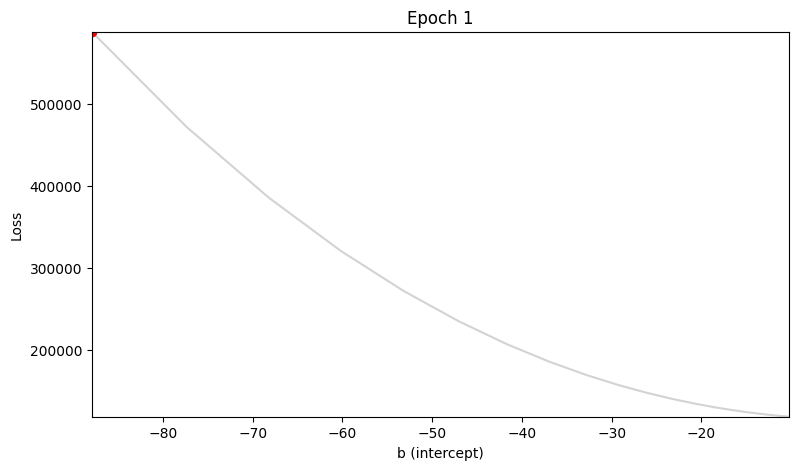

In [355]:
model2 = GDRegressor(learning_rate = 0.001, epochs = 20)
X = x.reshape(len(x))
Y = y.reshape(len(y))
model2.fit(X, Y)

fig, ax = plot.subplots(figsize=(9,5))

# full path (background curve)
ax.plot(model2.b_list, model2.loss_list, color="lightgray")

# moving dot
point, = ax.plot([], [], 'ro')

ax.set_xlabel("b (intercept)")
ax.set_ylabel("Loss")
ax.set_title("Loss vs b")

# limits
ax.set_xlim(min(model2.b_list), max(model2.b_list))
ax.set_ylim(min(model2.loss_list), max(model2.loss_list))

def update(i):
    point.set_data([model2.b_list[i]], [model2.loss_list[i]])
    ax.set_title(f"Epoch {i+1}")
    return point,

anim2 = FuncAnimation(fig, update,
                      frames=len(model2.b_list),
                      interval=500)

# save gif
anim2.save("animation2.gif", writer="pillow", fps=1)

# display
HTML(anim2.to_jshtml())

### **Loss function vs epochs**

Final b: -10.203410560197089
Final m: 80.76506039242432


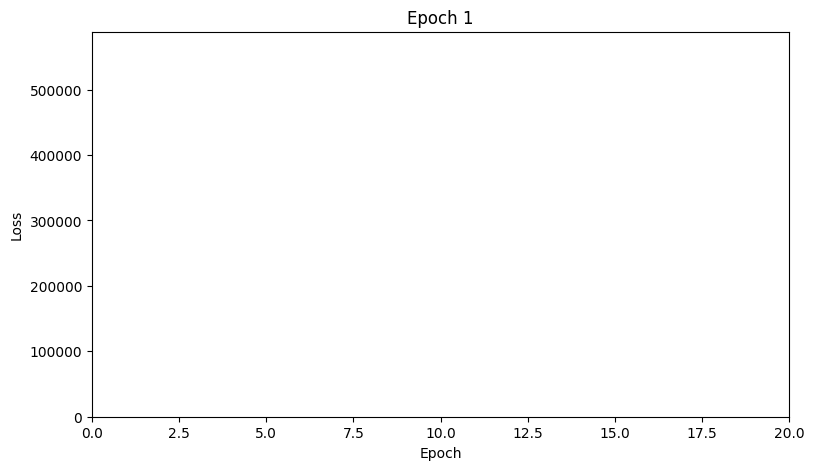

In [353]:
model3 = GDRegressor(learning_rate = 0.001, epochs = 20)
X = x.reshape(len(x))
Y = y.reshape(len(y))
model3.fit(X, Y)

fig, ax = plot.subplots(figsize=(9,5))

# line (initially empty)
line, = ax.plot([], [], color="#7700ff", linewidth=2)

ax.set_xlim(0, len(model3.loss_list))
ax.set_ylim(0, max(model3.loss_list))

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss vs Epoch")

def update(i):
    x_data = list(range(i+1))
    y_data = model3.loss_list[:i+1]

    line.set_data(x_data, y_data)
    ax.set_title(f"Epoch {i+1}")

    return line,

anim3 = FuncAnimation(fig, update,
                      frames=len(model3.loss_list),
                      interval=200)

# save gif
anim3.save("animation3.gif", writer="pillow", fps=5)

# display
HTML(anim3.to_jshtml())

### **b vs epochs**

Final b: -10.203410560197089
Final m: 80.76506039242432


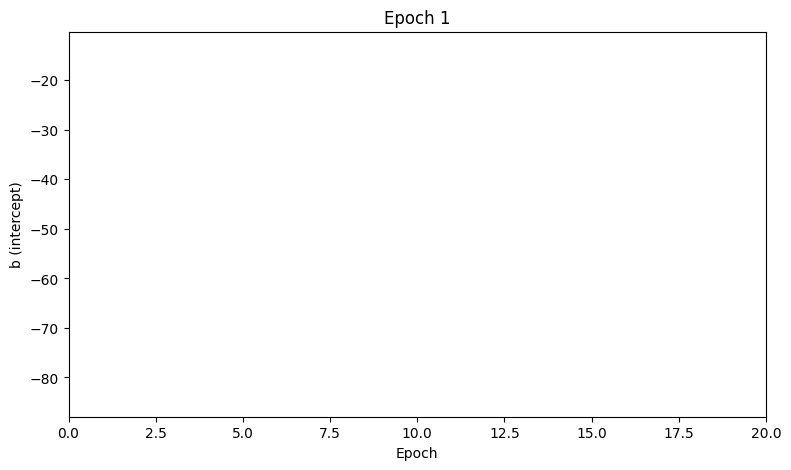

In [354]:
model4 = GDRegressor(learning_rate = 0.001, epochs = 20)
X = x.reshape(len(x))
Y = y.reshape(len(y))
model4.fit(X, Y)

fig, ax = plot.subplots(figsize=(9,5))

# line
line, = ax.plot([], [], color="#ff2989", linewidth=2)

ax.set_xlim(0, len(model4.b_list))
ax.set_ylim(min(model4.b_list), max(model4.b_list))

ax.set_xlabel("Epoch")
ax.set_ylabel("b (intercept)")
ax.set_title("b vs Epoch")

def update(i):
    x_data = list(range(i+1))
    y_data = model4.b_list[:i+1]

    line.set_data(x_data, y_data)
    ax.set_title(f"Epoch {i+1}")

    return line,

anim4 = FuncAnimation(fig, update,
                      frames=len(model4.b_list),
                      interval=200)

# save gif
anim4.save("animation4.gif", writer="pillow", fps=5)

# display
HTML(anim4.to_jshtml())